# Superdataset Feature Analysis

In [1]:
%load_ext autoreload
%autoreload 2

In [236]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import textwrap
import random
from sklearn.model_selection import RandomizedSearchCV, train_test_split, LearningCurveDisplay, learning_curve
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.svm import SVR
from sklearn.metrics import classification_report, mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform
import xgboost as xgb
import lightgbm as lgb
import shap

---

## Load superdataset

In [3]:
super_df = pd.read_csv('./DFA-data/merged_dfa_data_cleaned_2026_09_17.csv', dtype={"Participant_id": "str"})
super_df.shape

(10163, 64)

In [4]:
super_df.head()

,Participant_id,Last_Dental_Visit,Sex,Age,agegrp,Ethnicity_new,Race,dfs1,dfs2,dfs3,...,mdas5,source,count_missing,dfs_flag,idaf_flag,mdas_flag,dfs_total_score,dfs_avoidance_fear,dfs_specific_stimuli_fear,dfs_physiological_arousal
0,1,1,2,44,3,1,1,3,3,4,...,-9876,bph,0,1,1,0,69,18,26,20
1,2,1,2,56,5,1,1,1,1,3,...,-9876,bph,0,1,1,0,33,8,17,7
2,3,1,2,72,6,1,1,1,1,1,...,-9876,bph,0,1,1,0,25,8,11,5
3,6,1,2,36,3,1,1,1,1,1,...,-9876,bph,0,1,1,0,30,8,16,5
4,7,1,2,39,3,1,1,1,1,1,...,-9876,bph,0,1,1,0,23,8,9,5


---

## Define DFS features

In [5]:
# define subscale cols
dfs_subscale_cols = ['dfs_avoidance_fear', 'dfs_specific_stimuli_fear', 'dfs_physiological_arousal']

In [6]:
# get dfs cols excluding flag and subscales
dfs_cols = [
    col for col in super_df.columns 
    if col.startswith('dfs') and col != 'dfs_flag' and col not in dfs_subscale_cols
]
dfs_cols

['dfs1',
 'dfs2',
 'dfs3',
 'dfs4',
 'dfs5',
 'dfs6',
 'dfs7',
 'dfs8',
 'dfs9',
 'dfs10',
 'dfs11',
 'dfs12',
 'dfs13',
 'dfs14',
 'dfs15',
 'dfs16',
 'dfs17',
 'dfs18',
 'dfs19',
 'dfs20',
 'dfs_total_score']

## Build DFS particpants subset

In [7]:
# get rows for studies that used the dfs
subset_df = super_df[super_df['dfs_flag'] == 1]
subset_df.shape

(4540, 64)

In [8]:
# check sex distribution from each study / source
# 1=male, 2=female, 3=other, -9999=missing
subset_df[['source', 'Sex']].groupby(['source', 'Sex'])['Sex'].count()

source   Sex  
bph       1         19
          2        148
cohra1   -9999       1
          1        655
          2        988
cohra2    2       1484
f31       1         43
          2         59
randall  -9999       3
          1        314
          2        357
tic      -9999       1
          1        179
          2        278
          3         11
Name: Sex, dtype: int64

In [9]:
# check sex distribution
subset_df.groupby('Sex')['Sex'].count()

Sex
-9999       5
 1       1210
 2       3314
 3         11
Name: Sex, dtype: int64

In [10]:
# cohra2 only has females, so let's drop that study to keep dataset more balanced
subset_df = subset_df[subset_df['source'] != 'cohra2']
subset_df.shape

(3056, 64)

In [11]:
# check sex distribution
subset_df.groupby('Sex')['Sex'].count()

Sex
-9999       5
 1       1210
 2       1830
 3         11
Name: Sex, dtype: int64

In [12]:
# define some particpant relevant columns
participant_cols  = ['Participant_id', 'Last_Dental_Visit', 'Sex', 'Age']

In [13]:
# filter cols for only dfs questions
subset_df = subset_df[ participant_cols + dfs_cols]
subset_df.shape

(3056, 25)

In [14]:
subset_df.head()

,Participant_id,Last_Dental_Visit,Sex,Age,dfs1,dfs2,dfs3,dfs4,dfs5,dfs6,...,dfs12,dfs13,dfs14,dfs15,dfs16,dfs17,dfs18,dfs19,dfs20,dfs_total_score
0,1,1,2,44,3,3,4,5,5,1,...,2,2,5,5,5,5,5,1,5,69
1,2,1,2,56,1,1,3,1,1,1,...,1,1,2,2,4,4,4,1,1,33
2,3,1,2,72,1,1,1,1,1,1,...,1,1,4,3,1,1,1,1,1,25
3,6,1,2,36,1,1,1,1,1,1,...,1,1,3,3,3,3,3,1,1,30
4,7,1,2,39,1,1,1,1,1,1,...,1,1,1,1,2,2,2,1,1,23


In [15]:
# check for rows with null values
null_df = subset_df[subset_df.isnull().any(axis=1)]
len(null_df)

0

In [16]:
# check for missing values
# missing_df = subset_df[subset_df.select_dtypes('number').le(0).any(axis=1)]
missing_df = subset_df[(subset_df.select_dtypes('number') < 0).any(axis=1)]
len(missing_df)

354

In [17]:
missing_df.head()

,Participant_id,Last_Dental_Visit,Sex,Age,dfs1,dfs2,dfs3,dfs4,dfs5,dfs6,...,dfs12,dfs13,dfs14,dfs15,dfs16,dfs17,dfs18,dfs19,dfs20,dfs_total_score
23,27,-9999,2,62,2,2,4,4,4,4,...,4,3,5,5,5,5,5,1,5,70
97,120,2,2,65,1,1,1,-9999,1,1,...,1,1,1,2,1,1,1,2,1,-9999
98,129,1,2,74,1,1,1,1,1,5,...,1,1,5,5,5,3,5,-9999,1,-9999
138,115,1,2,-9999,1,1,1,1,1,1,...,1,1,1,2,2,2,3,1,1,25
145,124,1,2,61,1,1,5,1,1,1,...,1,1,2,-9999,1,1,3,1,3,-9999


In [18]:
# drop rows with missing values
super_df = super_df.drop(missing_df.index)
super_df.shape

(9809, 64)

In [19]:
# drop rows with missing values
subset_df = subset_df[~(subset_df == -9999).any(axis=1)]
subset_df.shape

(2702, 25)

---

## Correlations in DFS data  
The `spearman` method is used for ordninal data, but (I think) `kendall` can also be used.  

<Axes: >

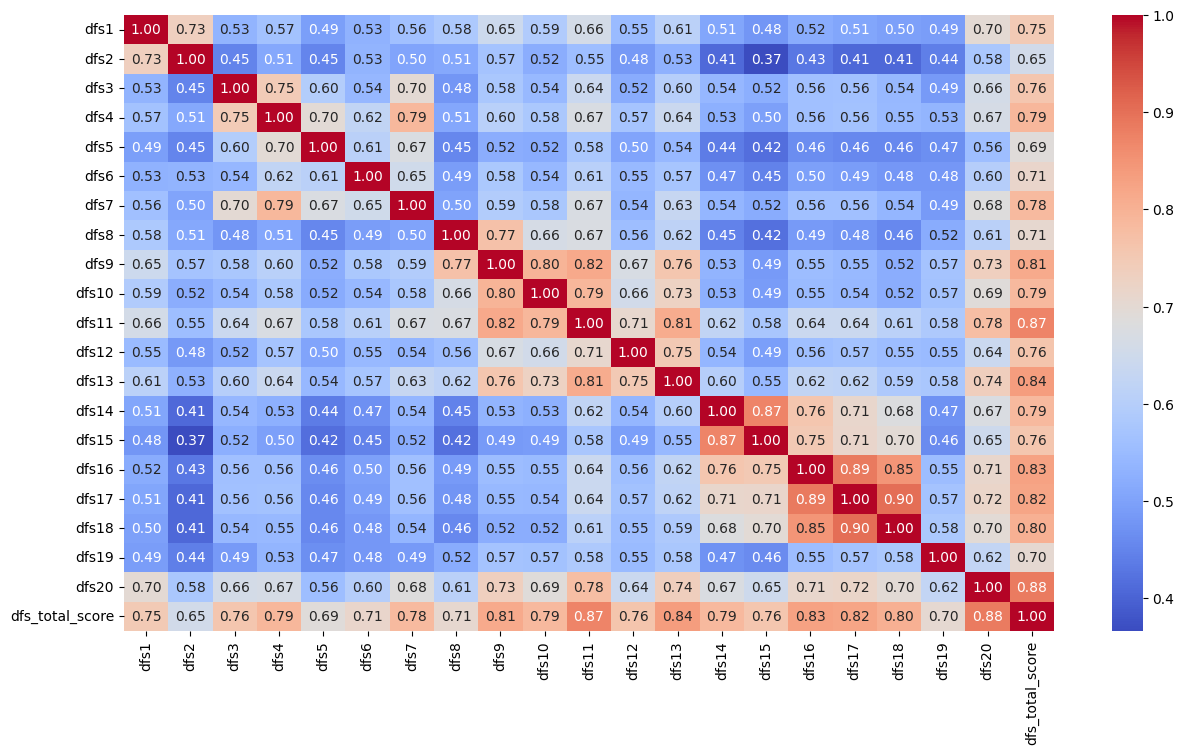

In [20]:
correlations = subset_df[dfs_cols].corr(method='pearson')
plt.figure(figsize=(15, 8)) # Adjust figure size as needed
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f")

## Plot counts for all DFS questions

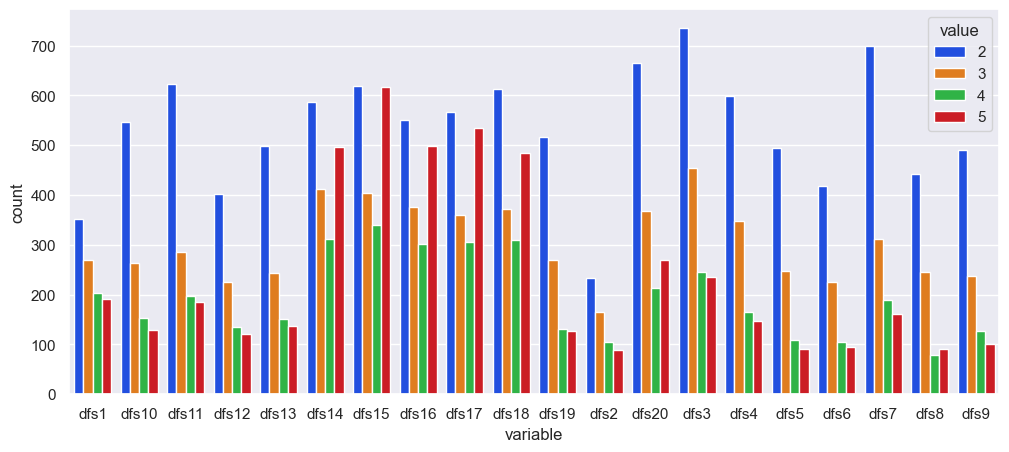

In [21]:
sns.set()
plt.figure(figsize=(12, 5))
plot_df = subset_df[dfs_cols].drop('dfs_total_score', axis=1).melt().groupby(['variable', 'value']).agg(count=('variable', 'size')).reset_index()
sns.barplot(
    data= plot_df[plot_df.value > 1],
    x='variable', 
    y='count',
    hue='value',
    palette='bright'
)
plt.show()

## Females vs Males DFS questions

<Figure size 1200x500 with 0 Axes>

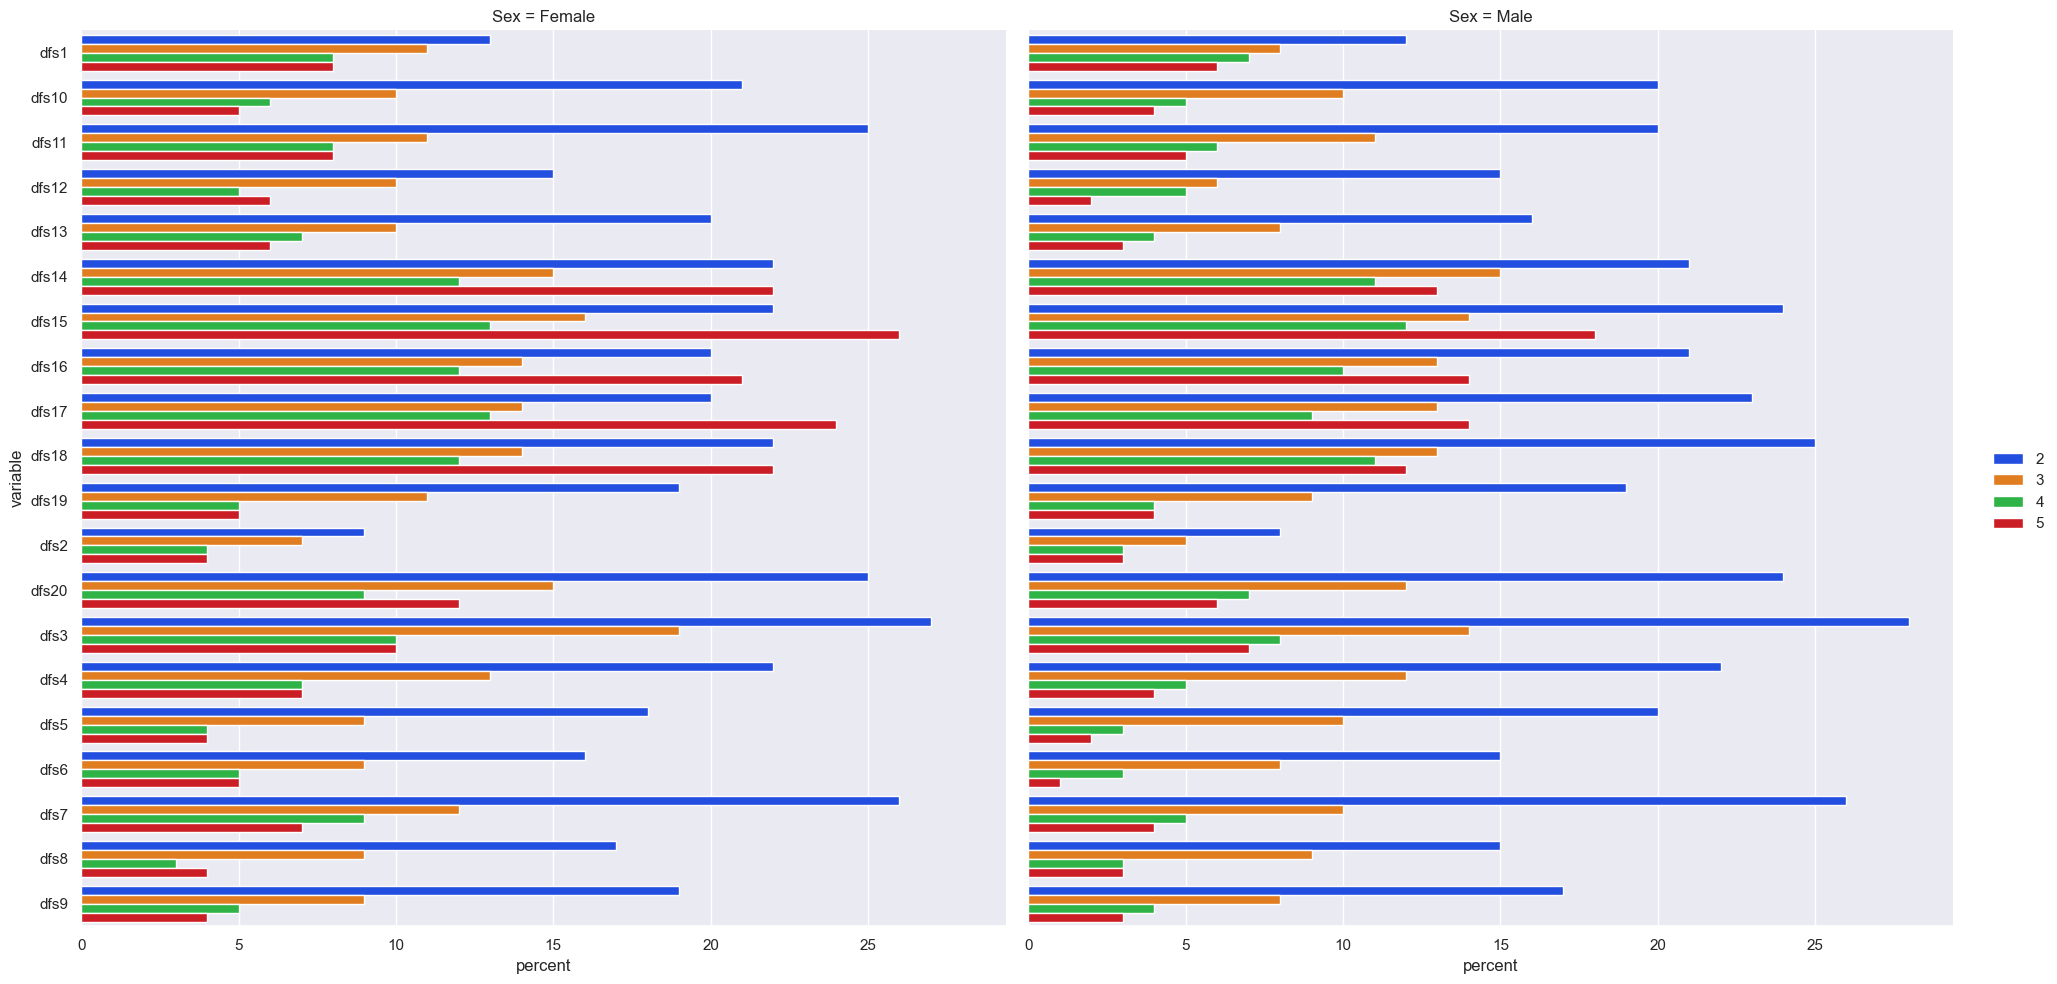

In [22]:
sns.set()
num_males = len(subset_df.Sex[subset_df.Sex==1])
num_females = len(subset_df.Sex[subset_df.Sex==2])

plt.figure(figsize=(12, 5))
plot_df = subset_df[['Sex'] + dfs_cols].drop('dfs_total_score', axis=1).melt(id_vars='Sex')
plot_df = plot_df.query('Sex > 0 and value > 1')
plot_df.Sex = np.where(plot_df.Sex == 1, 'Male', 'Female')
plot_df = plot_df.groupby(['Sex', 'variable', 'value']).agg(count=('variable', 'size')).reset_index()

plot_df['percent'] = plot_df.apply(
    lambda x: round(x['count']/num_males, 2) * 100 if x['Sex'] == 'Male' else round(x['count']/num_females, 2) * 100, axis=1
)

g = sns.FacetGrid(plot_df, col='Sex', height=10, aspect=1, sharey=True)
g.map_dataframe(sns.barplot, y='variable', x='percent', hue='value',  palette='bright')
g.add_legend()
g.tight_layout()

---

## Create train and test data

In [23]:
X = subset_df[dfs_cols].drop('dfs_total_score', axis=1)
y = subset_df['dfs_total_score']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

---

## ElasticNet — regularized linear model

In [25]:
enet_param_dist = {
    'alpha': uniform(0.001, 10),
    'l1_ratio': uniform(0, 1),
}

In [26]:
enet_random_search = RandomizedSearchCV(
    estimator=ElasticNet(random_state=42),
    param_distributions=enet_param_dist,
    n_iter=50,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

In [27]:
enet_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'alpha': <scipy.stats....t 0x147a973d0>, 'l1_ratio': <scipy.stats....t 0x147a97b50>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv

In [28]:
enet_model = enet_random_search.best_estimator_

In [29]:
enet_best_score = enet_random_search.best_score_
enet_best_params = enet_random_search.best_params_

In [30]:
print("Best ElasticNet score:", enet_best_score)
print("Best ElasticNet params:", enet_best_params)

Best ElasticNet score: -0.07721904278227498
Best ElasticNet params: {'alpha': 0.05622117123602399, 'l1_ratio': 0.8154614284548342}


In [31]:
enet_model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.05622117123602399
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.8154614284548342
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [32]:
y_pred = enet_model.predict(X_test)

In [33]:
print('r2_score:', r2_score(y_test, y_pred))
print('mean_squared_error:', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error:', root_mean_squared_error(y_test, y_pred))
print('mean_absolute_error:', mean_absolute_error(y_test, y_pred))

r2_score: 0.9999837887782415
mean_squared_error: 0.0060997256245135445
root_mean_squared_error: 0.07810074023025354
mean_absolute_error: 0.05654390496518252


In [34]:
enet_importances = pd.Series(enet_model.coef_, index=X_train.columns).sort_values(key=abs, ascending=True)

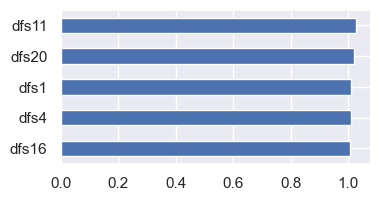

In [35]:
enet_importances.tail().plot(kind='barh', figsize=(4, 2))
plt.show()

In [36]:
enet_explainer = shap.LinearExplainer(enet_model, X_train)
enet_shap_values = enet_explainer.shap_values(X_test)

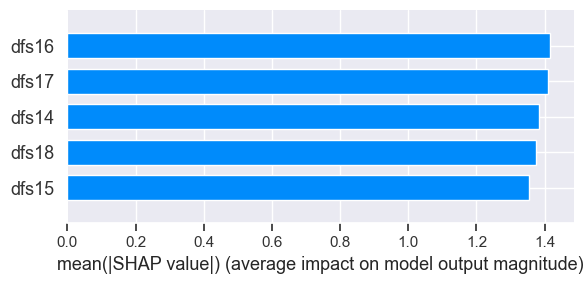

In [37]:
shap.summary_plot(enet_shap_values, X_test, plot_type='bar', max_display=5, plot_size=(6, 3))

**DFS 20**: All things considered, how fearful are you of having dental work done?  
**DFS 16**: Please rate how much fear, anxiety, or unpleasantness for *seeing the drill*.  
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.  
**DFS 4**: When having dental work done *my mbreathing rate increases*.

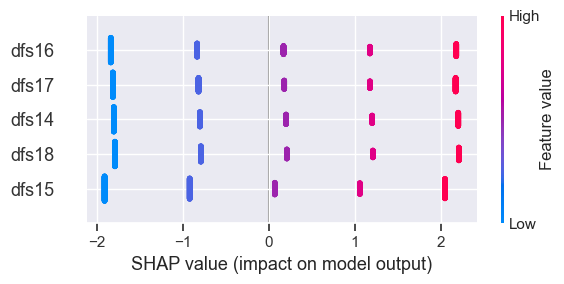

In [38]:
shap.summary_plot(enet_shap_values, X_test, max_display=5, plot_size=(6, 3))

---

## Lasso

In [39]:
lasso_param_dist = {
    'alpha': uniform(0.001, 10),
}

In [40]:
lasso_random_search = RandomizedSearchCV(
    estimator=Lasso(random_state=42),
    param_distributions=lasso_param_dist,
    n_iter=50,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

In [41]:
lasso_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'alpha': <scipy.stats....t 0x147cae610>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-f

In [42]:
lasso_model = lasso_random_search.best_estimator_

In [43]:
lasso_best_score = lasso_random_search.best_score_
lasso_best_params = lasso_random_search.best_params_

In [44]:
print("Best Lasso score:", lasso_best_score)
print("Best Lasso params:", lasso_best_params)

Best Lasso score: -0.2867575281283866
Best Lasso params: {'alpha': 0.20684494295802447}


In [45]:
y_pred = lasso_model.predict(X_test)

In [46]:
print('r2_score:', r2_score(y_test, y_pred))
print('mean_squared_error:', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error:', root_mean_squared_error(y_test, y_pred))
print('mean_absolute_error:', mean_absolute_error(y_test, y_pred))

r2_score: 0.999775939934926
mean_squared_error: 0.08430610232343949
root_mean_squared_error: 0.2903551313881666
mean_absolute_error: 0.20999860740344817


In [47]:
lasso_coefs = pd.Series(lasso_model.coef_, index=X_train.columns).sort_values(key=abs, ascending=True)

In [48]:
# How many features survived (nonzero)?
n_selected = (lasso_coefs != 0).sum()
print(f"{n_selected} of {len(lasso_coefs)} features have nonzero coefficients")

20 of 20 features have nonzero coefficients


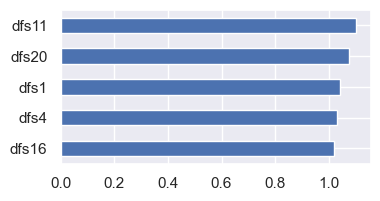

In [49]:
lasso_coefs.tail(5).plot(kind='barh', figsize=(4, 2))
plt.show()

In [50]:
lasso_explainer = shap.LinearExplainer(lasso_model, X_train)
lasso_shap_values = lasso_explainer(X_test)

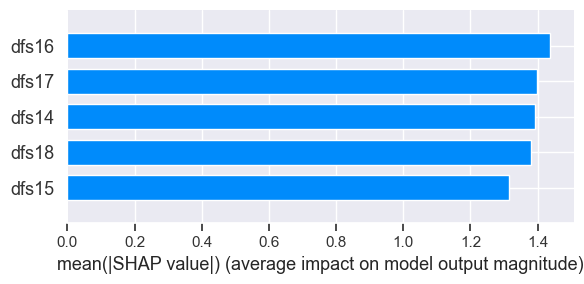

In [51]:
shap.summary_plot(lasso_shap_values, X_test, plot_type='bar', max_display=5, plot_size=(6, 3))

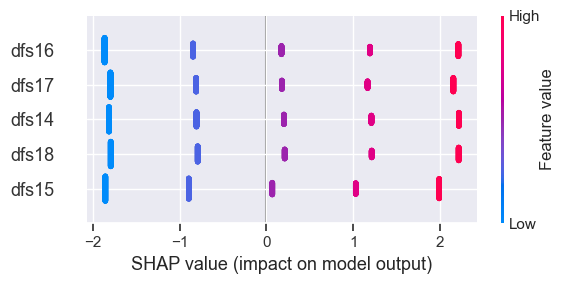

In [52]:
shap.summary_plot(lasso_shap_values, X_test, max_display=5, plot_size=(6, 3))

## Ridge

In [53]:
ridge_param_dist = {
    'alpha': uniform(0.001, 10),
}

In [54]:
ridge_random_search = RandomizedSearchCV(
    estimator=Ridge(random_state=42),
    param_distributions=ridge_param_dist,
    n_iter=50,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

In [55]:
ridge_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'alpha': <scipy.stats....t 0x147cc54d0>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-f

In [56]:
ridge_model = ridge_random_search.best_estimator_
ridge_best_score = ridge_random_search.best_score_
ridge_best_params = ridge_random_search.best_params_

In [57]:
print("Best Ridge score:", ridge_best_score)
print("Best Ridge params:", ridge_best_params)

Best Ridge score: -0.00019803021308274085
Best Ridge params: {'alpha': 0.20684494295802447}


In [58]:
y_pred = ridge_model.predict(X_test)

In [59]:
print('r2_score:', r2_score(y_test, y_pred))
print('mean_squared_error:', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error:', root_mean_squared_error(y_test, y_pred))
print('mean_absolute_error:', mean_absolute_error(y_test, y_pred))

r2_score: 0.9999999999316149
mean_squared_error: 2.573095012486512e-08
root_mean_squared_error: 0.0001604086971609243
mean_absolute_error: 0.00011602120775958636


In [60]:
ridge_coefs = pd.Series(ridge_model.coef_, index=X_train.columns).sort_values(key=abs, ascending=True)

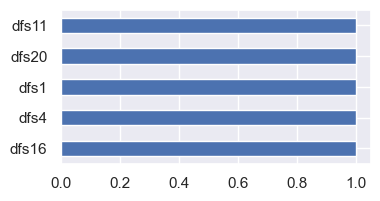

In [61]:
ridge_coefs.tail(5).plot(kind='barh', figsize=(4, 2))
plt.show()

In [62]:
ridge_explainer = shap.LinearExplainer(ridge_model, X_train)
ridge_shap_values = lasso_explainer(X_test)

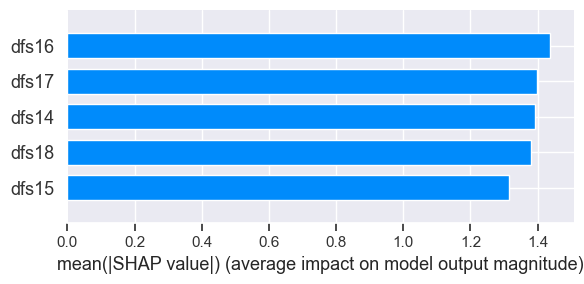

In [63]:
shap.summary_plot(ridge_shap_values, X_test, plot_type='bar', max_display=5, plot_size=(6, 3))

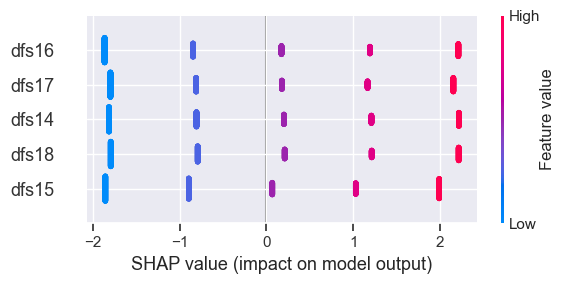

In [64]:
shap.summary_plot(ridge_shap_values, X_test, max_display=5, plot_size=(6, 3))

----

## Random forest variable importance

### Search for best paramaters

In [65]:
rf_param_dist = [
    {
        'n_estimators': randint(100, 500),
        'max_depth': [None, 5, 10, 15, 20, 30],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7, 1.0],
        'bootstrap': [True],
        'max_samples': [None, 0.5, 0.7, 0.9],
    },
    {
        'n_estimators': randint(100, 500),
        'max_depth': [None, 5, 10, 15, 20, 30],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7, 1.0],
        'bootstrap': [False],
        # no max_samples key here — invalid when bootstrap=False
    },
]

In [66]:
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=-1,
    error_score='raise'
)

In [67]:
rf_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'bootstrap': [True], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'max_samples': [None, 0.5, ...], ...}, {'bootstrap': [False], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': <scipy.stats....t 0x147f673d0>, ...}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are 

In [68]:
rf_model = rf_random_search.best_estimator_

In [69]:
rf_best_score = rf_random_search.best_score_
rf_best_params = rf_random_search.best_params_

In [70]:
print("Best RF score:", rf_best_score)
print("Best RF params:", rf_best_params)

Best RF score: -1.9084743817711143
Best RF params: {'bootstrap': False, 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 9, 'n_estimators': 227}


In [71]:
# Make predictions
y_pred = rf_model.predict(X_test)

In [72]:
print('r2_score:', r2_score(y_test, y_pred))
print('mean_squared_error:', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error:', root_mean_squared_error(y_test, y_pred))
print('mean_absolute_error:', mean_absolute_error(y_test, y_pred))
if rf_model.oob_score:
    print('oob_score_:', rf_model.oob_score_)

r2_score: 0.9909573911534559
mean_squared_error: 3.402422945988231
root_mean_squared_error: 1.844565787926316
mean_absolute_error: 1.217240068316037


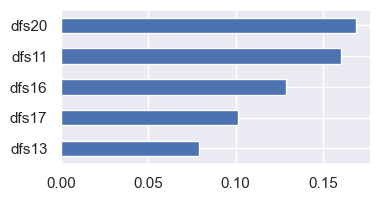

In [73]:
rf_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
# rf_importances.plot(kind='barh')
rf_importances.nlargest(5)[::-1].plot(kind='barh', figsize=(4, 2)) # to see top 5
plt.show()

**DFS 20**: All things considered, how fearful are you of having dental work done?  
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 16**: Please rate how much fear, anxiety, or unpleasantness for *seeing the drill*.  
**DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.  
**DFS 13**: Please rate how much fear, anxiety, or unpleasantness for *seeing the dentist walk in*.  
**DFS 18**: Please rate how much fear, anxiety, or unpleasantness for *feeling the vibrations of the drill*.

In [74]:
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_test)

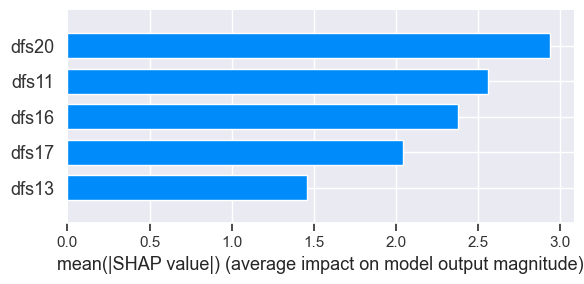

In [75]:
shap.summary_plot(rf_shap_values, X_test, plot_type='bar', max_display=5, plot_size=(6, 3))

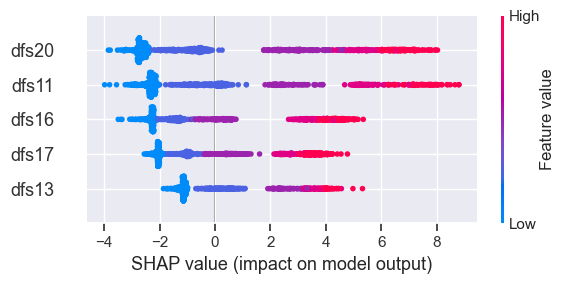

In [76]:
shap.summary_plot(rf_shap_values, X_test, max_display=5, plot_size=(6, 3))

---

## XGBoost

In [77]:
xgb_param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.01, 0.29),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 5),
    'reg_alpha': uniform(0, 5),
    'reg_lambda': uniform(0, 5),
}

In [78]:
xgb_random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=42, n_jobs=1, tree_method='hist'),
    param_distributions=xgb_param_dist,
    n_iter=100,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

In [79]:
xgb_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....t 0x147eaf310>, 'gamma': <scipy.stats....t 0x147e74710>, 'learning_rate': <scipy.stats....t 0x1473faa50>, 'max_depth': <scipy.stats....t 0x147c44b50>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer 

In [80]:
xgb_model = xgb_random_search.best_estimator_

In [81]:
xgb_best_score = xgb_random_search.best_score_
xgb_best_params = xgb_random_search.best_params_

In [82]:
print("Best XGB score:", xgb_best_score)
print("Best XGB params:", xgb_best_params)

Best XGB score: -1.2024428367614746
Best XGB params: {'colsample_bytree': 0.9746919954946938, 'gamma': 0.6876047207299663, 'learning_rate': 0.10890924180457495, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 250, 'reg_alpha': 2.707239869137829, 'reg_lambda': 3.478921996725411, 'subsample': 0.6914200087189198}


In [83]:
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9746919954946938
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

In [84]:
# Make predictions
y_pred = xgb_model.predict(X_test)

In [85]:
print('r2_score:', r2_score(y_test, y_pred))
print('mean_squared_error:', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error:', root_mean_squared_error(y_test, y_pred))
print('mean_absolute_error:', mean_absolute_error(y_test, y_pred))

r2_score: 0.9965136051177979
mean_squared_error: 1.3118001222610474
root_mean_squared_error: 1.1453384160995483
mean_absolute_error: 0.7297398447990417


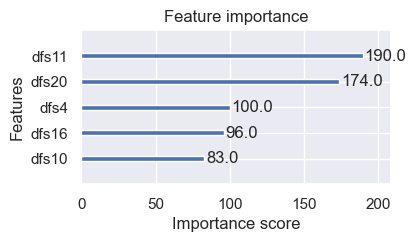

In [86]:
# Plot importance using default weight/gain
fig, ax = plt.subplots(figsize=(4, 2))
xgb.plot_importance(xgb_model, ax=ax, max_num_features=5)
plt.show()

**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 20**: All things considered, how fearful are you of having dental work done?  
**DFS 4**: When having dental work done *my breathing rate increases*.  
**DFS 16**: Please rate how much fear, anxiety, or unpleasantness for *seeing the drill*.  
**DFS 10**: Please rate how much fear, anxiety, or unpleasantness for *sitting in the waiting room*.  
**DFS 1**: Has fear of dental work ever caused you to put off making an appointment?  


In [87]:
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_test)

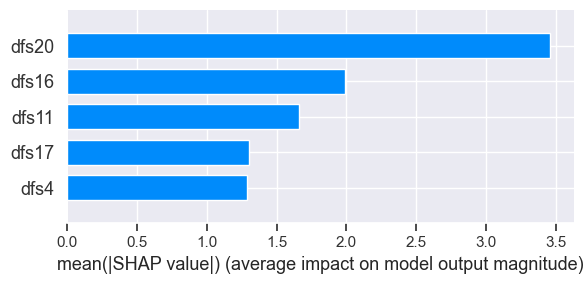

In [88]:
shap.summary_plot(xgb_shap_values, X_test, plot_type='bar', max_display=5, plot_size=(6, 3))

**DFS 20**: All things considered, how fearful are you of having dental work done?  
**DFS 16**: Please rate how much fear, anxiety, or unpleasantness for *seeing the drill*.  
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.  
**DFS 4**: When having dental work done *my mbreathing rate increases*.

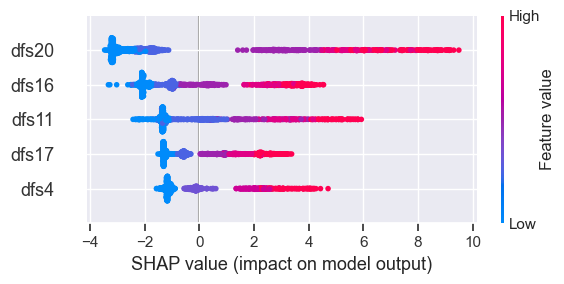

In [89]:
shap.summary_plot(xgb_shap_values, X_test, max_display=5, plot_size=(6, 3))

---

## LightGBM

In [90]:
lgb_param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.29),
    'num_leaves': randint(15, 100),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_samples': randint(5, 50),
    'reg_alpha': uniform(0, 5),
    'reg_lambda': uniform(0, 5),
}

In [91]:
lgb_random_search = RandomizedSearchCV(
    estimator=lgb.LGBMRegressor(random_state=42, n_jobs=1, verbose=-1),
    param_distributions=lgb_param_dist,
    n_iter=100,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

In [92]:
lgb_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMRegressor...2, verbose=-1)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....t 0x1480de850>, 'learning_rate': <scipy.stats....t 0x1480dae10>, 'max_depth': <scipy.stats....t 0x14829f290>, 'min_child_samples': <scipy.stats....t 0x1480de990>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across 

In [93]:
lgb_model = lgb_random_search.best_estimator_

In [94]:
lgb_best_score = lgb_random_search.best_score_
lgb_best_params = lgb_random_search.best_params_

In [95]:
print("Best LGB score:", lgb_best_score)
print("Best :GB params:", lgb_best_params)

Best LGB score: -1.1424444134037468
Best :GB params: {'colsample_bytree': 0.8607845038010402, 'learning_rate': 0.07503809974356233, 'max_depth': 3, 'min_child_samples': 8, 'n_estimators': 388, 'num_leaves': 28, 'reg_alpha': 1.6269984907963386, 'reg_lambda': 3.732457025590121, 'subsample': 0.8598531596188859}


In [96]:
lgb_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,28
,max_depth,3
,learning_rate,0.07503809974356233
,n_estimators,388
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,8


In [97]:
y_pred = lgb_model.predict(X_test)

In [98]:
print('r2_score:', r2_score(y_test, y_pred))
print('mean_squared_error:', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error:', root_mean_squared_error(y_test, y_pred))
print('mean_absolute_error:', mean_absolute_error(y_test, y_pred))

r2_score: 0.9964511672552947
mean_squared_error: 1.3353038008134446
root_mean_squared_error: 1.155553460820158
mean_absolute_error: 0.7193650611352661


In [99]:
lgb_importances = pd.Series(lgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)

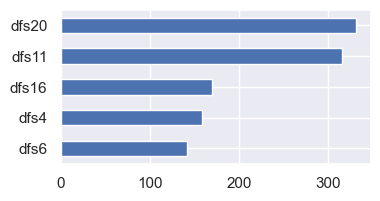

In [100]:
lgb_importances.tail().plot(kind='barh', figsize=(4, 2))
plt.show()

In [101]:
lgb_explainer = shap.TreeExplainer(lgb_model)
lgb_shap_values = lgb_explainer(X_test)

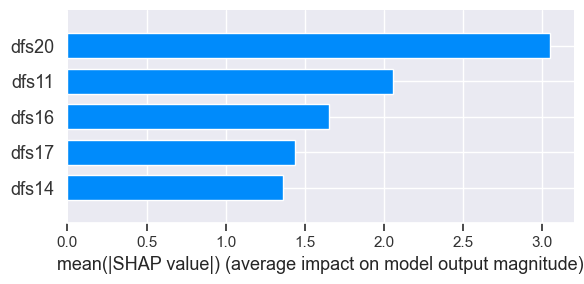

In [102]:
shap.summary_plot(lgb_shap_values, X_test, plot_type='bar', max_display=5, plot_size=(6, 3))

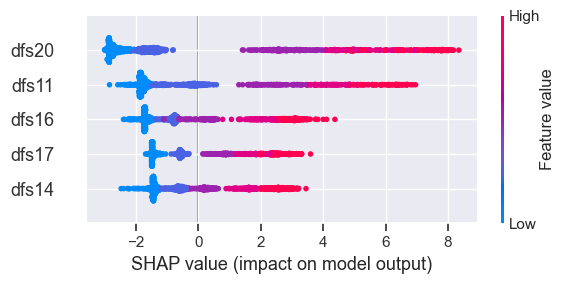

In [103]:
shap.summary_plot(lgb_shap_values, X_test, max_display=5, plot_size=(6, 3))

---

## HistGradientBoostingRegressor

In [104]:
hgb_param_dist = {
    'max_iter': randint(100, 400),
    'max_depth': [None, 5, 10, 15],
    'learning_rate': uniform(0.01, 0.29),
    'l2_regularization': uniform(0, 5),
    'max_leaf_nodes': randint(15, 100),
}

In [105]:
hgb_random_search = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=42),
    param_distributions=hgb_param_dist,
    n_iter=100,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

In [106]:
hgb_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'l2_regularization': <scipy.stats....t 0x1481be8d0>, 'learning_rate': <scipy.stats....t 0x1481be810>, 'max_depth': [None, 5, ...], 'max_iter': <scipy.stats....t 0x1480d9410>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Gui

In [107]:
hgb_model = hgb_random_search.best_estimator_

In [108]:
hgb_best_score = hgb_random_search.best_score_
hgb_best_params = hgb_random_search.best_params_

In [109]:
print("Best HGB score:", hgb_best_score)
print("Best HGB params:", hgb_best_params)

Best HGB score: -1.4326073327984234
Best HGB params: {'l2_regularization': 3.047821669899484, 'learning_rate': 0.15577691673636984, 'max_depth': 5, 'max_iter': 323, 'max_leaf_nodes': 15}


In [110]:
hgb_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.15577691673636984
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",323
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",15
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",5
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",3.047821669899484
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature

In [111]:
y_pred = hgb_model.predict(X_test)

In [112]:
print('r2_score:', r2_score(y_test, y_pred))
print('mean_squared_error:', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error:', root_mean_squared_error(y_test, y_pred))
print('mean_absolute_error:', mean_absolute_error(y_test, y_pred))

r2_score: 0.994382962128067
mean_squared_error: 2.1134983131835776
root_mean_squared_error: 1.4537875749859666
mean_absolute_error: 0.8510792763201708


In [113]:
hgb_permutation_result = permutation_importance(hgb_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

In [114]:
hgb_importances = pd.Series(hgb_permutation_result.importances_mean, index=X_test.columns).sort_values(ascending=True)

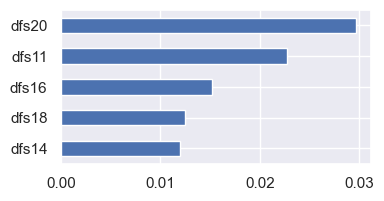

In [115]:
hgb_importances.tail().plot(kind='barh', figsize=(4, 2))
plt.show()

In [116]:
hgb_explainer = shap.TreeExplainer(hgb_model)
hgb_shap_values = hgb_explainer(X_test)

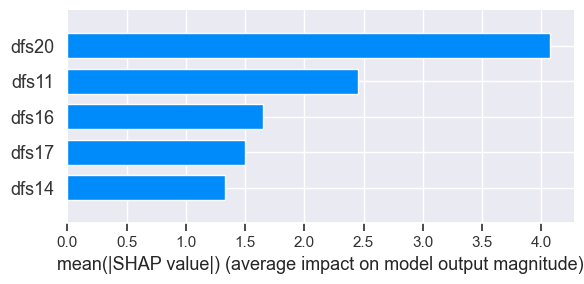

In [117]:
shap.summary_plot(hgb_shap_values, X_test, plot_type='bar', max_display=5, plot_size=(6, 3))

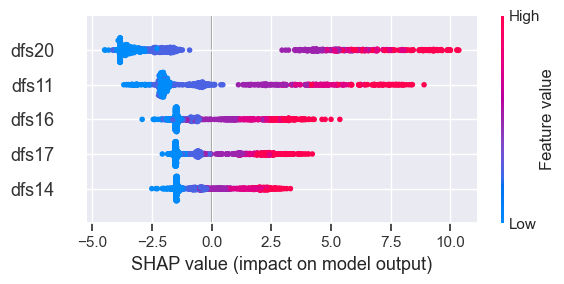

In [118]:
shap.summary_plot(hgb_shap_values, X_test, max_display=5, plot_size=(6, 3))

---

## Support Vector Regression (SVR)

In [119]:
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR()),
])

In [120]:
svr_param_dist = {
    'C': uniform(0.1, 100),
    'epsilon': uniform(0.01, 1),
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto'],
}

In [121]:
# param names need the 'svr__' prefix to target the pipeline step
svr_param_dist_pipeline = {f'svr__{k}': v for k, v in svr_param_dist.items()}

In [122]:
svr_random_search = RandomizedSearchCV(
    estimator=svr_pipeline,
    param_distributions=svr_param_dist_pipeline,
    n_iter=50,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

In [123]:
svr_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svr', SVR())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svr__C': <scipy.stats....t 0x147fc5090>, 'svr__epsilon': <scipy.stats....t 0x148293350>, 'svr__gamma': ['scale', 'auto'], 'svr__kernel': ['rbf', 'linear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscr

In [124]:
svr_model = svr_random_search.best_estimator_

In [125]:
svr_best_score = svr_random_search.best_score_
svr_best_params = svr_random_search.best_params_

In [126]:
print("Best SVR score:", svr_best_score)
print("Best SVR params:", svr_best_params)

Best SVR score: -0.02267269306896853
Best SVR params: {'svr__C': 70.90725777960455, 'svr__epsilon': 0.03058449429580245, 'svr__gamma': 'auto', 'svr__kernel': 'linear'}


In [127]:
svr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [128]:
y_pred = svr_model.predict(X_test)

In [129]:
print('r2_score:', r2_score(y_test, y_pred))
print('mean_squared_error:', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error:', root_mean_squared_error(y_test, y_pred))
print('mean_absolute_error:', mean_absolute_error(y_test, y_pred))

r2_score: 0.9999984690436924
mean_squared_error: 0.0005760462448997902
root_mean_squared_error: 0.02400096341607541
mean_absolute_error: 0.02167026208339784


In [130]:
svr_permutation_result = permutation_importance(svr_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

In [131]:
svr_importances = pd.Series(svr_permutation_result.importances_mean, index=X_test.columns).sort_values(ascending=True)

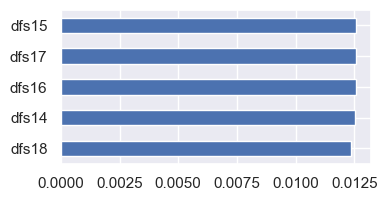

In [132]:
svr_importances.tail().plot(kind='barh', figsize=(4, 2))
plt.show()

In [133]:
# SVR has no fast exact explainer, so use KernelExplainer with a small
# background sample for the baseline and a subsample of X_test to explain
# (KernelExplainer is model-agnostic but slow — scales poorly with rows/features)

background = shap.sample(X_train, 100, random_state=42)
X_test_sample = X_test.sample(200, random_state=42)
X_test_sample_values = X_test_sample.values

In [134]:
def svr_predict_fn(X):
    X_df = pd.DataFrame(X, columns=X_train.columns)
    return svr_model.predict(X_df)

In [135]:
svr_explainer = shap.KernelExplainer(svr_predict_fn, background)
svr_shap_values = svr_explainer.shap_values(X_test_sample_values)

  0%|          | 0/200 [00:00<?, ?it/s]

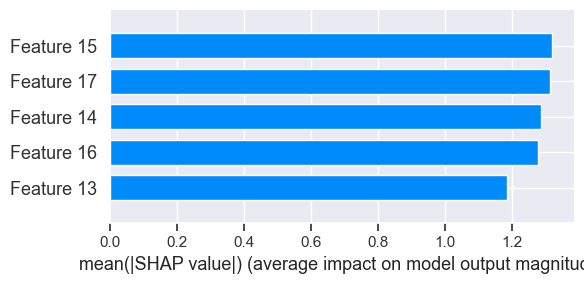

In [136]:
shap.summary_plot(svr_shap_values, X_test_sample_values, plot_type='bar', max_display=5, plot_size=(6, 3))

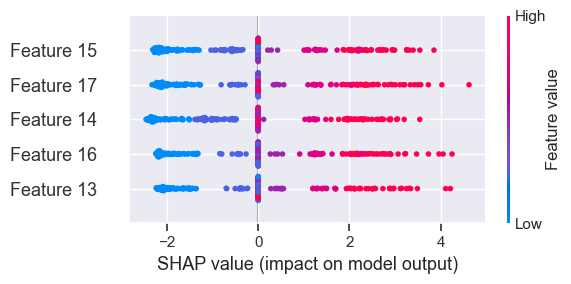

In [137]:
shap.summary_plot(svr_shap_values, X_test_sample_values, max_display=5, plot_size=(6, 3))

---

## Compare and Visualize Results

### helper functions

In [219]:
def get_shap_array(shap_values):
    return shap_values.values if hasattr(shap_values, 'values') else shap_values

In [228]:
def rank_feature_counts_long(rank_df, top_n=None, include_models=False):
    """
    Long-format hierarchical table: (Rank, Feature) -> Count [, Models].
    Excludes zero-count entries automatically.
    """
    df = rank_df.head(top_n) if top_n else rank_df

    records = []
    for rank in df.index:
        row = df.loc[rank]
        for feature in row.unique():
            models = row[row == feature].index.tolist()
            record = {'Rank': rank, 'Feature': feature, 'Count': len(models)}
            if include_models:
                record['Models'] = ', '.join(models)
            records.append(record)

    result = pd.DataFrame(records)
    result = result.sort_values(['Rank', 'Count'], ascending=[True, False])
    result = result.set_index(['Rank', 'Feature'])
    return result

In [182]:
def soften_color(hex_color, amount=0.55):
    """Blend a color toward white. amount=0 -> no change, amount=1 -> pure white."""
    rgb = mcolors.to_rgb(hex_color)
    white = (1, 1, 1)
    softened = tuple(c + (w - c) * amount for c, w in zip(rgb, white))
    return mcolors.to_hex(softened)

In [183]:
def build_feature_color_map(*dfs, cmap_name='tab20', softness=0.55):
    """Build a consistent feature -> soft color mapping across one or more ranking DataFrames."""
    all_features = pd.unique(pd.concat([pd.Series(df.values.ravel()) for df in dfs]))

    cmap1 = plt.get_cmap('tab20')
    cmap2 = plt.get_cmap('tab20b')
    combined_colors = [cmap1(i) for i in range(20)] + [cmap2(i) for i in range(20)]
    colors = [mcolors.to_hex(c) for c in combined_colors[:len(all_features)]]
    colors = [soften_color(c, amount=softness) for c in colors]

    return dict(zip(all_features, colors))

In [190]:
def style_rank_table(df, feature_color_map):
    """Apply consistent per-feature background coloring to a ranking DataFrame."""
    def color_by_feature(val):
        color = feature_color_map.get(val, '#ffffff')
        rgb = mcolors.to_rgb(color)
        luminance = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
        text_color = 'black' if luminance > 0.5 else 'white'
        return f'background-color: {color}; color: {text_color}'

    return df.style.map(color_by_feature)

In [169]:
def top_n_feature_counts(rank_df, top_n=5):
    """Count how many models rank each feature in their top N."""
    return pd.Series(rank_df.head(top_n).values.ravel()).value_counts()

In [198]:
def rank_position_counts(rank_df, top_n=None):
    """Count how many models assign each feature to each rank position."""
    df = rank_df.head(top_n) if top_n else rank_df
    counts = df.apply(pd.Series.value_counts, axis=1).fillna(0).astype(int)
    counts = counts.loc[:, (counts != 0).any(axis=0)]  # drop all-zero columns
    return counts

In [170]:
def compare_top_n_counts(rank_df_a, rank_df_b, top_n=5, names=('a', 'b')):
    """Compare top-N frequency between two ranking tables (e.g., native vs. SHAP)."""
    counts_a = top_n_feature_counts(rank_df_a, top_n=top_n)
    counts_b = top_n_feature_counts(rank_df_b, top_n=top_n)

    comparison = pd.DataFrame({
        f'{names[0]}_count': counts_a,
        f'{names[1]}_count': counts_b,
    }).fillna(0).astype(int)

    comparison = comparison.sort_values(f'{names[0]}_count', ascending=False)
    return comparison

In [179]:
def plot_top_n_counts(counts, top_n=5, title=None, figsize=(6, 3)):
    """Bar plot of feature frequency within top N across models."""
    counts.sort_values().plot(kind='barh', figsize=figsize)
    plt.xlabel(f'Number of models (top {top_n})')
    plt.title(title or f'Feature Frequency in Top {top_n} Across Models')
    # plt.tight_layout()
    plt.show()

In [266]:
def build_model_annotations(rank_df, top_n=None, model_abbrev=None):
    """
    Build a (counts, annotations) pair for a rank heatmap where each cell
    shows both the count and the list of models that assigned that
    feature to that rank, e.g. "3\nRF, XGB, LGB".

    Parameters
    ----------
    rank_df : pd.DataFrame
        A ranking table like native_rank_df or shap_rank_table: rows are
        rank positions (1, 2, 3, ...), columns are model names, and each
        cell holds the feature name that model ranked at that position.

    top_n : int or None, default None
        If set, only build annotations for the top N ranks. If None,
        uses all ranks in rank_df.

    model_abbrev : dict or None, default None
        Optional mapping of {full_model_name: short_name} used to shorten
        model names in the annotation text, e.g.
        {"RandomForest": "RF", "XGBoost": "XGB"}. Any model not in the
        dict is shown with its full name. If None, full names are used.

    Returns
    -------
    counts : pd.DataFrame
        Rank x Feature grid of counts (how many models ranked each
        feature at each rank). Used to drive the heatmap's color scale.

    annot : pd.DataFrame
        Same shape as counts, but each cell is a string like
        "3\nRF, XGB, LGB" (or '' where the count is 0). Pass this to
        plot_rank_heatmap(..., annot=annot) to show model names inside
        each cell instead of just the count.

    Example
    -------
    >>> counts, annot = build_model_annotations(native_rank_df, top_n=5, model_abbrev=model_abbrev)
    >>> plot_rank_heatmap(counts, annot=annot, title='Native — Rank Frequency & Models')
    """
    long_df = rank_feature_counts_long(rank_df, top_n=top_n, include_models=True)

    counts = long_df['Count'].unstack(fill_value=0)
    annot = counts.astype(str).copy()

    for (rank, feature), row in long_df.iterrows():
        models_list = [m.strip() for m in row['Models'].split(',')]
        if model_abbrev:
            models_list = [model_abbrev.get(m, m) for m in models_list]
        models_str = ', '.join(models_list)
        annot.loc[rank, feature] = f"{row['Count']}\n{models_str}"

    annot = annot.where(counts != 0, '')  # blank out cells with no models
    return counts, annot

In [267]:
def plot_rank_heatmap(
    rank_counts, annot=None, figsize=(12, 5), cmap='Blues',
    title='Feature Rank Frequency Across Models', annot_fontsize=8,
):
    """
    Draw a single heatmap of rank_counts (rank x feature -> count of
    models).

    Parameters
    ----------
    rank_counts : pd.DataFrame
        Rank x Feature grid of counts, e.g. from rank_position_counts()
        or the first element returned by build_model_annotations().
        Drives both the cell color and (if annot is None) the displayed
        number.

    annot : pd.DataFrame or None, default None
        Optional string DataFrame the same shape as rank_counts (e.g.
        the second element returned by build_model_annotations()). If
        given, its text is shown in each cell instead of the raw count
        — typically "count\nmodel names". If None, the plain count is
        shown in each cell.

    figsize : tuple, default (12, 5)
        Figure size in inches (width, height). Widen this if annot text
        (model names) is getting cut off or crowded.

    cmap : str, default 'Blues'
        Matplotlib/seaborn colormap for the heatmap's color scale.

    title : str, default 'Feature Rank Frequency Across Models'
        Plot title.

    annot_fontsize : int, default 8
        Font size for the text inside each cell. Lower this if cells
        with model names look cramped.

    Example
    -------
    >>> # counts only
    >>> plot_rank_heatmap(rank_position_counts(native_rank_df, top_n=5))

    >>> # counts + model names
    >>> counts, annot = build_model_annotations(native_rank_df, top_n=5, model_abbrev=model_abbrev)
    >>> plot_rank_heatmap(counts, annot=annot, figsize=(14, 6))
    """
    plt.figure(figsize=figsize)
    sns.heatmap(
        rank_counts,
        annot=annot if annot is not None else True,
        fmt='' if annot is not None else 'd',
        cmap=cmap,
        cbar_kws={'label': 'Number of models'},
        annot_kws={'fontsize': annot_fontsize},
    )
    plt.xlabel('Feature')
    plt.ylabel('Rank')
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [268]:
def plot_rank_heatmaps_side_by_side(
    rank_counts_list, titles, annot_list=None, figsize=(16, 5), cmap='Blues', annot_fontsize=8,
):
    """
    Draw multiple rank-count heatmaps side by side, sharing one color
    scale and one colorbar — useful for comparing e.g. native importance
    vs. SHAP rank frequency.

    Parameters
    ----------
    rank_counts_list : list of pd.DataFrame
        A list of Rank x Feature count grids (e.g.
        [native_counts, shap_counts]), one per panel. All panels share
        the same color scale, computed from the combined min/max across
        every table in this list.

    titles : list of str
        Panel titles, one per entry in rank_counts_list, in the same
        order.

    annot_list : list of pd.DataFrame or None, default None
        Optional list of string DataFrames (same shapes as
        rank_counts_list) to show model names in each panel's cells,
        e.g. [native_annot, shap_annot] from build_model_annotations().
        If None, plain counts are shown in every panel.

    figsize : tuple, default (16, 5)
        Overall figure size in inches (width, height). Widen this when
        annot_list is used, since model-name text needs more room per
        cell.

    cmap : str, default 'Blues'
        Matplotlib/seaborn colormap shared by all panels.

    annot_fontsize : int, default 8
        Font size for the text inside each cell across all panels.

    Example
    -------
    >>> native_counts, native_annot = build_model_annotations(native_rank_df, top_n=5, model_abbrev=model_abbrev)
    >>> shap_counts, shap_annot = build_model_annotations(shap_rank_table, top_n=5, model_abbrev=model_abbrev)
    >>> plot_rank_heatmaps_side_by_side(
    ...     [native_counts, shap_counts],
    ...     titles=['Native Importance', 'SHAP'],
    ...     annot_list=[native_annot, shap_annot],
    ...     figsize=(20, 6),
    ... )
    """
    n = len(rank_counts_list)
    vmin = min(rc.values.min() for rc in rank_counts_list)
    vmax = max(rc.values.max() for rc in rank_counts_list)

    fig, axes = plt.subplots(
        1, n + 1, figsize=figsize,
        gridspec_kw={'width_ratios': [1] * n + [0.05]},
        constrained_layout=True,
    )
    heatmap_axes, cbar_ax = axes[:n], axes[n]

    for i, (ax, rank_counts, title) in enumerate(zip(heatmap_axes, rank_counts_list, titles)):
        annot = annot_list[i] if annot_list else True
        fmt = '' if annot_list else 'd'
        sns.heatmap(
            rank_counts, annot=annot, fmt=fmt, cmap=cmap,
            vmin=vmin, vmax=vmax, ax=ax,
            cbar=(i == n - 1), cbar_ax=cbar_ax if i == n - 1 else None,
            annot_kws={'fontsize': annot_fontsize},
        )
        ax.set_xlabel('Feature')
        ax.set_ylabel('Rank')
        ax.set_title(title)

    cbar_ax.set_ylabel('Number of models')
    plt.show()

In [210]:
def align_rank_counts(*rank_counts_list):
    """Reindex a list of rank-count DataFrames to share the same columns and row order."""
    all_features = sorted(set().union(*(rc.columns for rc in rank_counts_list)))
    return [rc.reindex(columns=all_features, fill_value=0) for rc in rank_counts_list]

In [264]:
def bar_plot_rank_composition(
    long_df,
    figsize=(10, 5),
    cmap_name='tab20',
    softness=0.45,
    fontsize=12,
    fontweight='normal',
    show_models=True,
    models_fontsize=None,
    wrap_width=30,
    model_abbrev=None,
    show_legend=True,
    legend_fontsize=None,
    legend_loc='right',   # 'right' or 'bottom'
    legend_cols=4,        # only used when legend_loc='bottom'
):
    """
    Stacked horizontal bar chart showing, for each rank position, which
    features were assigned that rank by how many models (and by which
    models).

    Parameters
    ----------
    long_df : pd.DataFrame
        Output of rank_feature_counts_long(rank_df, top_n=..., include_models=True).
        Must have a MultiIndex (Rank, Feature) and a 'Count' column.
        Include a 'Models' column (via include_models=True) to show model
        names under each segment and to enable the legend.

    figsize : tuple, default (10, 5)
        Overall figure size in inches (width, height). Increase width if
        legend_loc='right' and the legend feels cramped.

    cmap_name : str, default 'tab20'
        Matplotlib colormap used to assign a distinct base color to each
        feature before softening.

    softness : float, default 0.45
        How much to blend each feature's color toward white (0 = full
        saturation, 1 = white). Higher = softer/lighter bar colors.

    fontsize : int, default 10
        Base font size for the "{feature} ({count})" labels, axis ticks,
        and y-axis rank labels. Title is fontsize + 2.

    fontweight : str, default 'normal'
        Font weight for the feature/count labels (e.g., 'normal', 'bold').

    show_models : bool, default True
        If True and long_df has a 'Models' column, prints the list of
        models under each segment's feature/count label.

    models_fontsize : int or None, default None
        Font size for the models text under each segment. Defaults to
        fontsize - 2 (minimum 6) if not set.

    wrap_width : int, default 20
        Max characters per line before wrapping the models text. Lower
        this if model names are long or segments are narrow.

    model_abbrev : dict or None, default None
        Optional mapping of {full_model_name: short_name} used to shorten
        model names in both the models text and the legend, e.g.
        {"RandomForest": "RF", "XGBoost": "XGB"}. Any model not in the
        dict is shown with its full name.

    show_legend : bool, default True
        If True, show_models=True, and model_abbrev is provided, adds a
        legend mapping each abbreviation back to its full model name.

    legend_fontsize : int or None, default None
        Font size for the legend text. Defaults to fontsize if not set.

    legend_loc : str, default 'right'
        Where to place the legend: 'right' (vertical list beside the
        plot, avoids overlapping the x-axis) or 'bottom' (grid below
        the plot).

    legend_cols : int, default 4
        Number of abbreviation entries per row. Only used when
        legend_loc='bottom'.

    Example
    -------
    >>> native_long = rank_feature_counts_long(native_rank_df, top_n=5, include_models=True)
    >>> model_abbrev = {
    ...     "RandomForest": "RF", "XGBoost": "XGB", "LightGBM": "LGB",
    ...     "HistGB": "HGB", "ElasticNet": "EN", "Ridge": "Ridge",
    ...     "Lasso": "Lasso", "SVR": "SVR",
    ... }
    >>> bar_plot_rank_composition(
    ...     native_long,
    ...     figsize=(13, 6),
    ...     model_abbrev=model_abbrev,
    ...     show_legend=True,
    ...     legend_loc='right',
    ... )

    Minimal call (no models text, no legend):
    >>> bar_plot_rank_composition(native_long, show_models=False, show_legend=False)
    """
    ranks = long_df.index.get_level_values('Rank').unique().sort_values()
    all_features = long_df.index.get_level_values('Feature').unique()

    cmap = plt.colormaps.get_cmap(cmap_name).resampled(len(all_features))
    feature_colors = {
        f: soften_color(mcolors.to_hex(cmap(i)), amount=softness)
        for i, f in enumerate(all_features)
    }

    models_fontsize = models_fontsize or max(fontsize - 2, 6)
    legend_fontsize = legend_fontsize or fontsize
    has_models_col = 'Models' in long_df.columns
    model_abbrev = model_abbrev or {}

    fig, ax = plt.subplots(figsize=figsize)

    for rank in ranks:
        left = 0
        row_data = long_df.loc[rank]
        for feature, data in row_data.iterrows():
            count = data['Count']
            color = feature_colors[feature]

            ax.barh(rank, count, left=left, color=color, edgecolor='white')

            rgb = mcolors.to_rgb(color)
            luminance = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
            text_color = 'black' if luminance > 0.6 else 'white'

            ax.text(
                left + count / 2, rank - 0.15,
                f"{feature} ({count})",
                ha='center', va='center',
                fontsize=fontsize, fontweight=fontweight, color=text_color,
            )

            if show_models and has_models_col:
                models_list = [m.strip() for m in data['Models'].split(',')]
                models_list = [model_abbrev.get(m, m) for m in models_list]
                models_str = ', '.join(models_list)
                wrapped_models = '\n'.join(textwrap.wrap(models_str, width=wrap_width))
                ax.text(
                    left + count / 2, rank + 0.2,
                    wrapped_models,
                    ha='center', va='top',
                    fontsize=models_fontsize, color=text_color,
                )

            left += count

    ax.set_yticks(ranks)
    ax.set_yticklabels([f'Rank {r}' for r in ranks], fontsize=fontsize)
    ax.invert_yaxis()
    ax.set_xlabel('Number of models', fontsize=fontsize)
    ax.set_title('Feature Composition by Rank', fontsize=fontsize + 2)
    ax.tick_params(axis='x', labelsize=fontsize)

    if show_legend and show_models and model_abbrev:
        items = [f"{abbrev} = {full}" for full, abbrev in model_abbrev.items()]

        if legend_loc == 'right':
            legend_text = '\n'.join(items)
            fig.subplots_adjust(right=0.78)
            fig.text(
                0.80, 0.5, legend_text,
                ha='left', va='center', fontsize=legend_fontsize,
                linespacing=2.0,
            )
        else:  # 'bottom'
            n_rows = -(-len(items) // legend_cols)  # ceil division
            rows = [items[i:i + legend_cols] for i in range(0, len(items), legend_cols)]
            legend_text = '\n'.join('     '.join(row) for row in rows)

            bottom_margin = 0.08 + 0.05 * n_rows
            fig.subplots_adjust(bottom=bottom_margin)
            fig.text(
                0.5, bottom_margin - 0.05, legend_text,
                ha='center', va='top', fontsize=legend_fontsize,
                linespacing=1.8,
            )

    plt.show()

### comparison shap rankings

In [220]:
# For each model, get features sorted by importance (most important first)
shap_rankings = {
    'RandomForest': pd.Series(np.abs(get_shap_array(rf_shap_values)).mean(axis=0), index=X_test.columns).sort_values(ascending=False).index.tolist(),
    'XGBoost': pd.Series(np.abs(get_shap_array(xgb_shap_values)).mean(axis=0), index=X_test.columns).sort_values(ascending=False).index.tolist(),
    'LightGBM': pd.Series(np.abs(get_shap_array(lgb_shap_values)).mean(axis=0), index=X_test.columns).sort_values(ascending=False).index.tolist(),
    'HistGB': pd.Series(np.abs(get_shap_array(hgb_shap_values)).mean(axis=0), index=X_test.columns).sort_values(ascending=False).index.tolist(),
    'ElasticNet': pd.Series(np.abs(get_shap_array(enet_shap_values)).mean(axis=0), index=X_test.columns).sort_values(ascending=False).index.tolist(),
    'Ridge': pd.Series(np.abs(get_shap_array(ridge_shap_values)).mean(axis=0), index=X_test.columns).sort_values(ascending=False).index.tolist(),
    'Lasso': pd.Series(np.abs(get_shap_array(lasso_shap_values)).mean(axis=0), index=X_test.columns).sort_values(ascending=False).index.tolist(),
    'SVR': pd.Series(np.abs(get_shap_array(svr_shap_values)).mean(axis=0), index=X_test_sample.columns).sort_values(ascending=False).index.tolist(),
}


In [221]:
# Build a table: rows = rank (1st, 2nd, 3rd...), columns = model
shap_rank_df = pd.DataFrame(shap_rankings)
shap_rank_df.index = shap_rank_df.index + 1
shap_rank_df.index.name = 'Rank'
shap_rank_df

,RandomForest,XGBoost,LightGBM,HistGB,ElasticNet,Ridge,Lasso,SVR
Rank,,,,,,,,
1,dfs20,dfs20,dfs20,dfs20,dfs16,dfs16,dfs16,dfs16
2,dfs11,dfs16,dfs11,dfs11,dfs17,dfs17,dfs17,dfs18
3,dfs16,dfs11,dfs16,dfs16,dfs14,dfs14,dfs14,dfs15
4,dfs17,dfs17,dfs17,dfs17,dfs18,dfs18,dfs18,dfs17
5,dfs13,dfs4,dfs14,dfs14,dfs15,dfs15,dfs15,dfs14
6,dfs18,dfs15,dfs18,dfs18,dfs20,dfs20,dfs20,dfs11
7,dfs14,dfs18,dfs15,dfs4,dfs3,dfs3,dfs3,dfs20
8,dfs9,dfs14,dfs1,dfs15,dfs1,dfs1,dfs1,dfs7
9,dfs4,dfs1,dfs4,dfs1,dfs7,dfs11,dfs11,dfs4


### compare Native Feature Importances (e.g., coeficients and permutations)

In [222]:
native_rankings = {
    'RandomForest': pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).index.tolist(),
    'XGBoost': pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).index.tolist(),
    'LightGBM': pd.Series(lgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).index.tolist(),
    'HistGB': hgb_importances.index.tolist(),  # via permutation_importance — no native feature_importances_
    'ElasticNet': pd.Series(np.abs(enet_model.coef_), index=X_train.columns).sort_values(ascending=False).index.tolist(),
    'Ridge': pd.Series(np.abs(ridge_model.coef_), index=X_train.columns).sort_values(ascending=False).index.tolist(),
    'Lasso': pd.Series(np.abs(lasso_model.coef_), index=X_train.columns).sort_values(ascending=False).index.tolist(),
    'SVR': svr_importances.index.tolist(),  # via permutation_importance — no native importance for nonlinear kernel
}

In [153]:
native_rank_df = pd.DataFrame(native_rankings)
native_rank_df.index = native_rank_df.index + 1
native_rank_df.index.name = 'Rank'
native_rank_df

,RandomForest,XGBoost,LightGBM,HistGB,ElasticNet,Ridge,Lasso,SVR
Rank,,,,,,,,
1,dfs20,dfs20,dfs20,dfs9,dfs11,dfs11,dfs11,dfs5
2,dfs11,dfs16,dfs11,dfs5,dfs20,dfs20,dfs20,dfs8
3,dfs16,dfs11,dfs16,dfs8,dfs1,dfs1,dfs1,dfs2
4,dfs17,dfs13,dfs4,dfs13,dfs4,dfs4,dfs4,dfs6
5,dfs13,dfs4,dfs6,dfs6,dfs16,dfs16,dfs16,dfs9
6,dfs18,dfs17,dfs18,dfs2,dfs14,dfs14,dfs14,dfs19
7,dfs9,dfs9,dfs15,dfs12,dfs18,dfs18,dfs18,dfs12
8,dfs14,dfs14,dfs1,dfs19,dfs17,dfs17,dfs17,dfs4
9,dfs4,dfs18,dfs13,dfs10,dfs9,dfs9,dfs9,dfs10


In [225]:
native_value_counts = pd.Series(native_rank_df.head(3).values.ravel()).value_counts()
native_value_counts

dfs20    6
dfs11    6
dfs16    3
dfs1     3
dfs5     2
dfs8     2
dfs9     1
dfs2     1
Name: count, dtype: int64

In [229]:
rank_feature_counts_long(native_rank_df, top_n=5, include_models=True)

Count                              Models
Rank Feature                                           
1    dfs20        3     RandomForest, XGBoost, LightGBM
     dfs11        3            ElasticNet, Ridge, Lasso
     dfs9         1                              HistGB
     dfs5         1                                 SVR
2    dfs20        3            ElasticNet, Ridge, Lasso
     dfs11        2              RandomForest, LightGBM
     dfs16        1                             XGBoost
     dfs5         1                              HistGB
     dfs8         1                                 SVR
3    dfs1         3            ElasticNet, Ridge, Lasso
     dfs16        2              RandomForest, LightGBM
     dfs11        1                             XGBoost
     dfs8         1                              HistGB
     dfs2         1                                 SVR
4    dfs4         4  LightGBM, ElasticNet, Ridge, Lasso
     dfs13        2                     XGBoost, HistGB
     dfs17        1                        RandomForest
     dfs6         1                                 SVR
5    dfs16        3            ElasticNet, Ridge, Lasso
     dfs6         2                    LightGBM, HistGB
     dfs13        1                        RandomForest
     dfs4         1                             XGBoost
     dfs9         1                                 SVR

In [223]:
comparison = compare_top_n_counts(native_rank_df, shap_rank_table, top_n=5, names=('native', 'shap'))
comparison

,native_count,shap_count
dfs11,6,4
dfs16,6,8
dfs20,6,4
dfs4,5,1
dfs1,3,0
dfs13,3,1
dfs6,3,0
dfs5,2,0
dfs8,2,0
dfs9,2,0


### visualizations

In [193]:
feature_color_map = build_feature_color_map(native_rank_df, shap_rank_table, softness=0.7)

In [194]:
style_rank_table(shap_rank_df.head(), feature_color_map)

,RandomForest,XGBoost,LightGBM,HistGB,ElasticNet,Ridge,Lasso,SVR
Rank,,,,,,,,
1,dfs20,dfs20,dfs20,dfs20,dfs16,dfs16,dfs16,dfs16
2,dfs11,dfs16,dfs11,dfs11,dfs17,dfs17,dfs17,dfs18
3,dfs16,dfs11,dfs16,dfs16,dfs14,dfs14,dfs14,dfs15
4,dfs17,dfs17,dfs17,dfs17,dfs18,dfs18,dfs18,dfs17
5,dfs13,dfs4,dfs14,dfs14,dfs15,dfs15,dfs15,dfs14


In [195]:
style_rank_table(native_rank_df.head(), feature_color_map)

,RandomForest,XGBoost,LightGBM,HistGB,ElasticNet,Ridge,Lasso,SVR
Rank,,,,,,,,
1,dfs20,dfs20,dfs20,dfs9,dfs11,dfs11,dfs11,dfs5
2,dfs11,dfs16,dfs11,dfs5,dfs20,dfs20,dfs20,dfs8
3,dfs16,dfs11,dfs16,dfs8,dfs1,dfs1,dfs1,dfs2
4,dfs17,dfs13,dfs4,dfs13,dfs4,dfs4,dfs4,dfs6
5,dfs13,dfs4,dfs6,dfs6,dfs16,dfs16,dfs16,dfs9


In [224]:
rank_position_counts(native_rank_df)  

,dfs1,dfs10,dfs11,dfs12,dfs13,dfs14,dfs15,dfs16,dfs17,dfs18,dfs19,dfs2,dfs20,dfs3,dfs4,dfs5,dfs6,dfs7,dfs8,dfs9
Rank,,,,,,,,,,,,,,,,,,,,
1,0,0,3,0,0,0,0,0,0,0,0,0,3,0,0,1,0,0,0,1
2,0,0,2,0,0,0,0,1,0,0,0,0,3,0,0,1,0,0,1,0
3,3,0,1,0,0,0,0,2,0,0,0,1,0,0,0,0,0,0,1,0
4,0,0,0,0,2,0,0,0,1,0,0,0,0,0,4,0,1,0,0,0
5,0,0,0,0,1,0,0,3,0,0,0,0,0,0,1,0,2,0,0,1
6,0,0,0,0,0,3,0,0,1,2,1,1,0,0,0,0,0,0,0,0
7,0,0,0,2,0,0,1,0,0,3,0,0,0,0,0,0,0,0,0,2
8,1,0,0,0,0,2,0,0,3,0,1,0,0,0,1,0,0,0,0,0
9,0,2,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,3


In [167]:
native_value_counts = pd.Series(native_rank_df.head(3).values.ravel()).value_counts()
native_value_counts

dfs20    6
dfs11    6
dfs16    3
dfs1     3
dfs5     2
dfs8     2
dfs9     1
dfs2     1
Name: count, dtype: int64

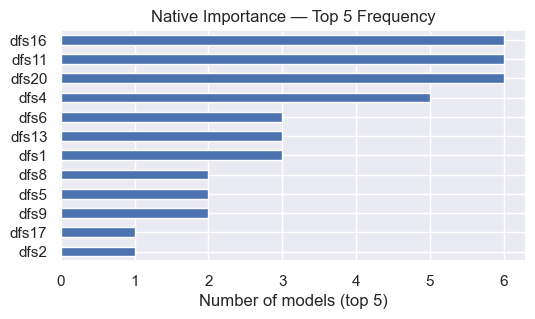

In [180]:
native_top5 = top_n_feature_counts(native_rank_df, top_n=5)
plot_top_n_counts(native_top5, top_n=5, title='Native Importance — Top 5 Frequency')

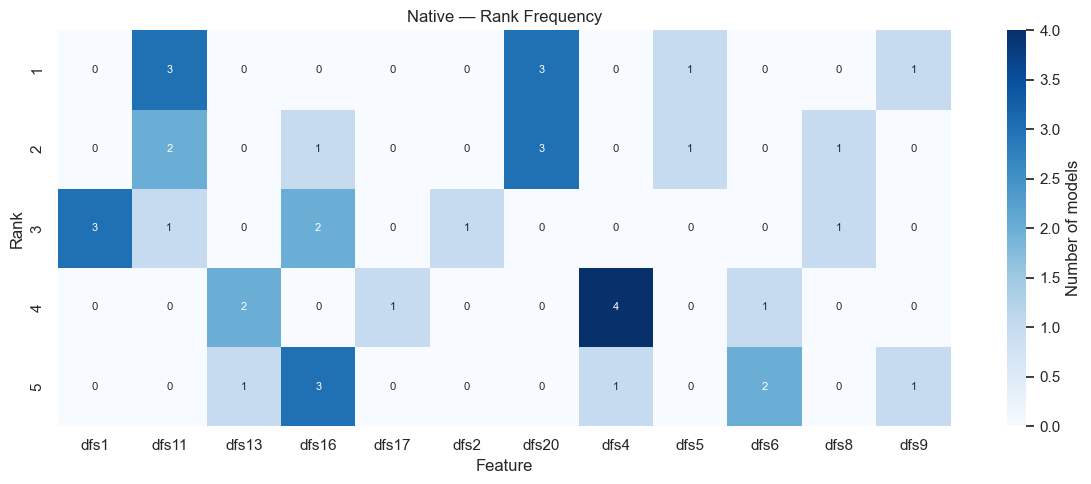

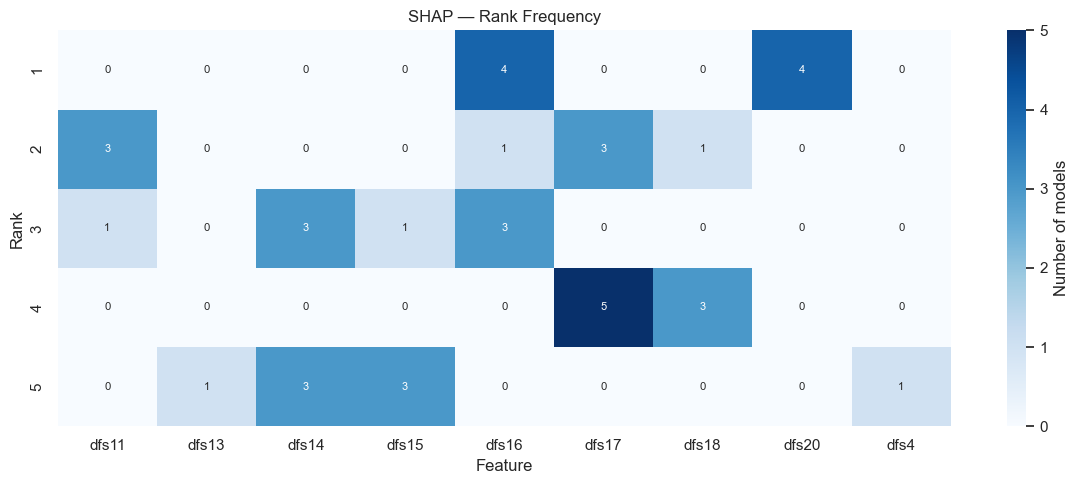

In [270]:
plot_rank_heatmap(rank_position_counts(native_rank_df, top_n=5), title='Native — Rank Frequency')
plot_rank_heatmap(rank_position_counts(shap_rank_table, top_n=5), title='SHAP — Rank Frequency')

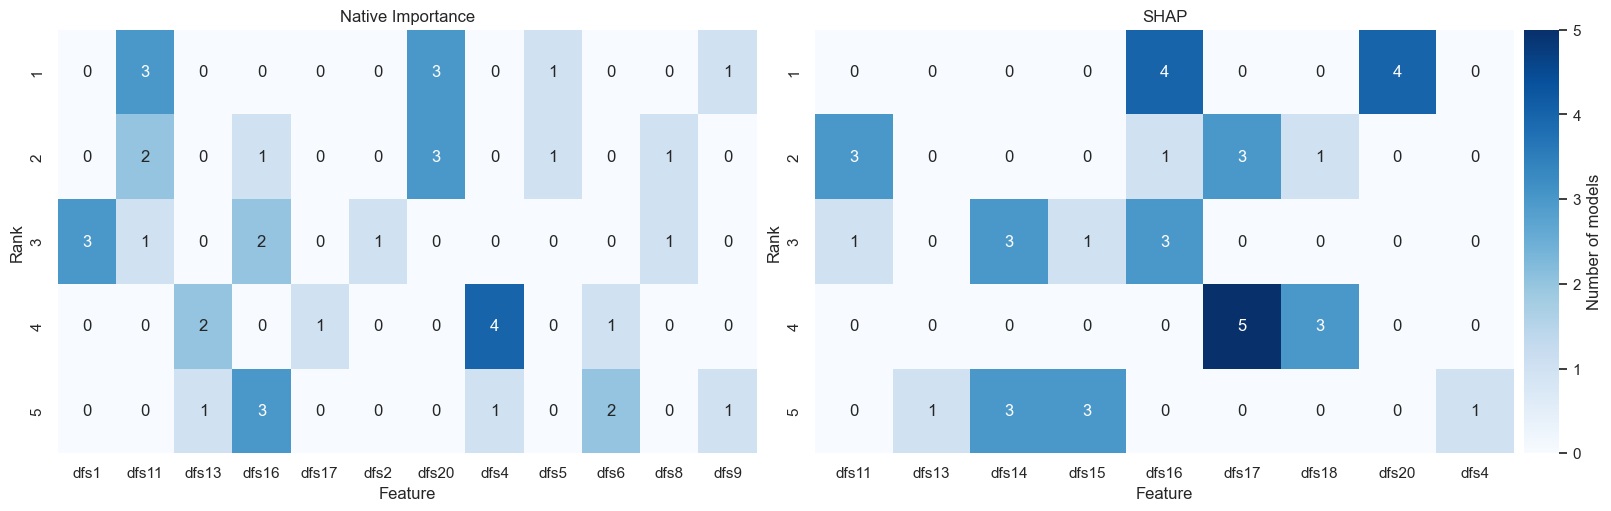

In [216]:
native_counts = rank_position_counts(native_rank_df, top_n=5)
shap_counts = rank_position_counts(shap_rank_table, top_n=5)

plot_rank_heatmaps_side_by_side(
    [native_counts, shap_counts],
    titles=['Native Importance', 'SHAP'],
)

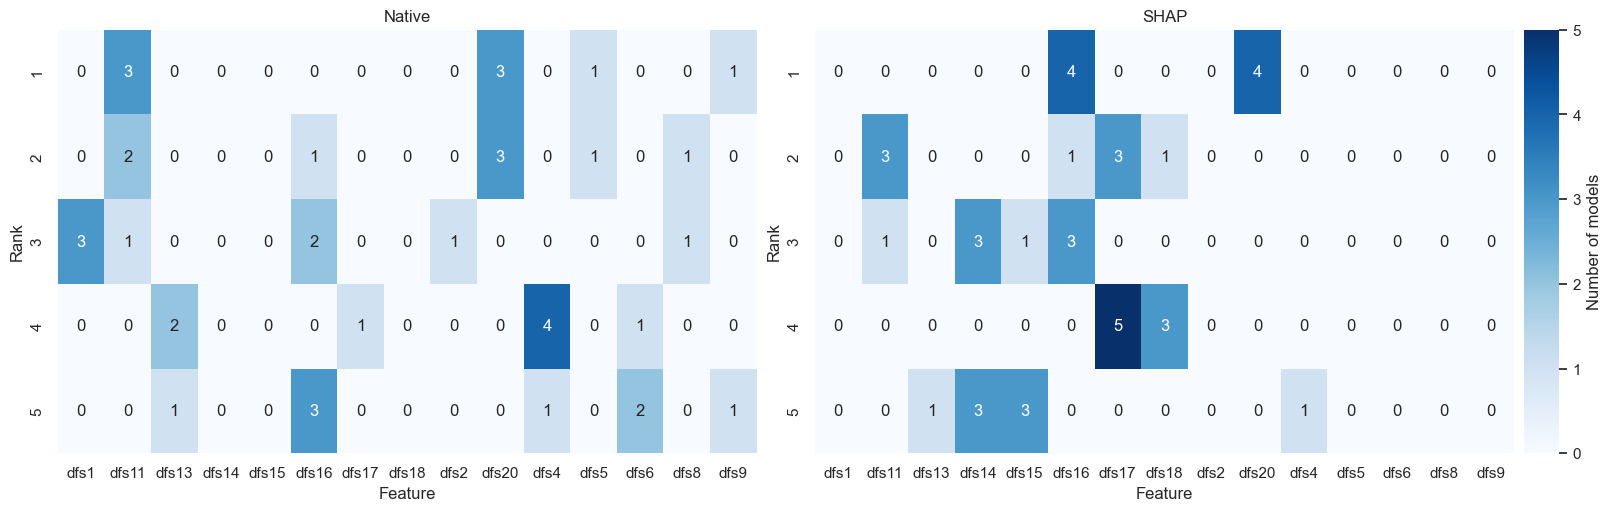

In [217]:
native_counts, shap_counts = align_rank_counts(native_counts, shap_counts)
plot_rank_heatmaps_side_by_side([native_counts, shap_counts], titles=['Native', 'SHAP'])

In [272]:
model_abbrev = {
    "RandomForest": "RF",
    "XGBoost": "XGB",
    "LightGBM": "LGB",
    "HistGB": "HGB",
    "ElasticNet": "EN",
    "Ridge": "RDG",
    "Lasso": "LSO",
    "SVR": "SVR",
}

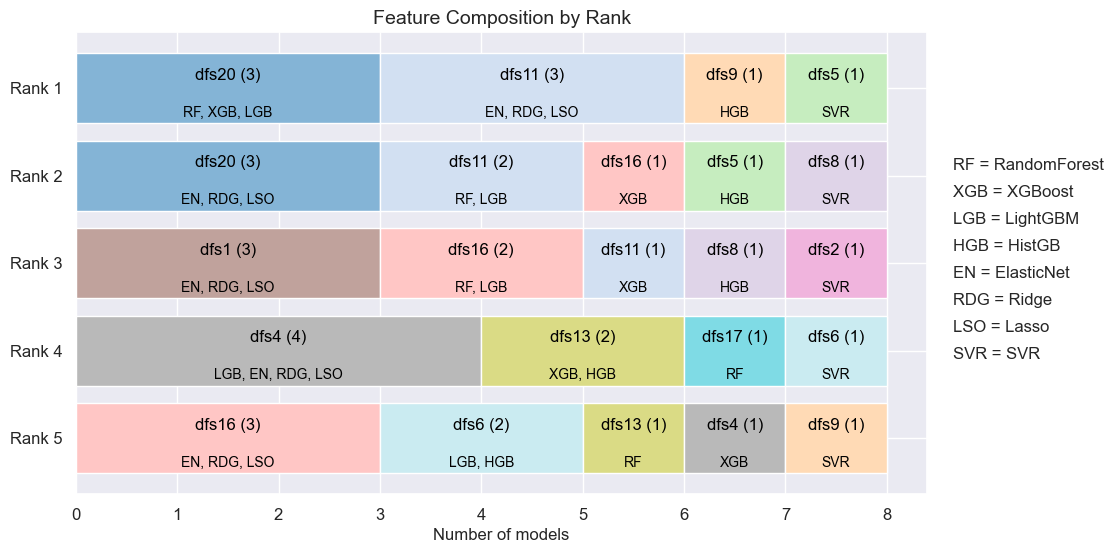

In [273]:
native_long = rank_feature_counts_long(native_rank_df, top_n=5, include_models=True)
bar_plot_rank_composition(native_long, figsize=(13, 6), model_abbrev=model_abbrev, legend_loc='right', wrap_width=30, fontsize=12)

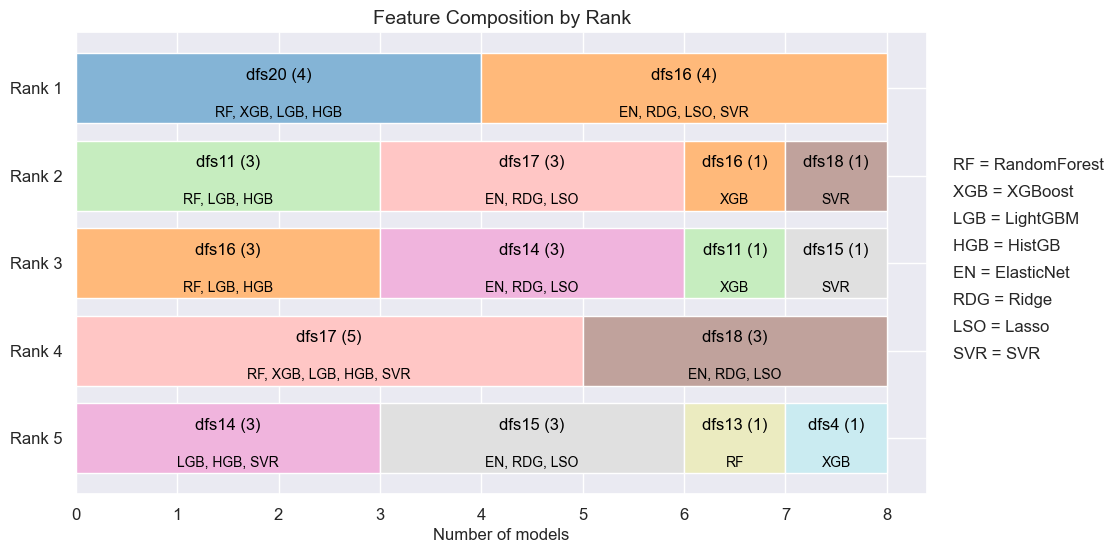

In [274]:
shap_long = rank_feature_counts_long(shap_rank_df, top_n=5, include_models=True)
bar_plot_rank_composition(shap_long, figsize=(13, 6), model_abbrev=model_abbrev, legend_loc='right', wrap_width=30, fontsize=12)

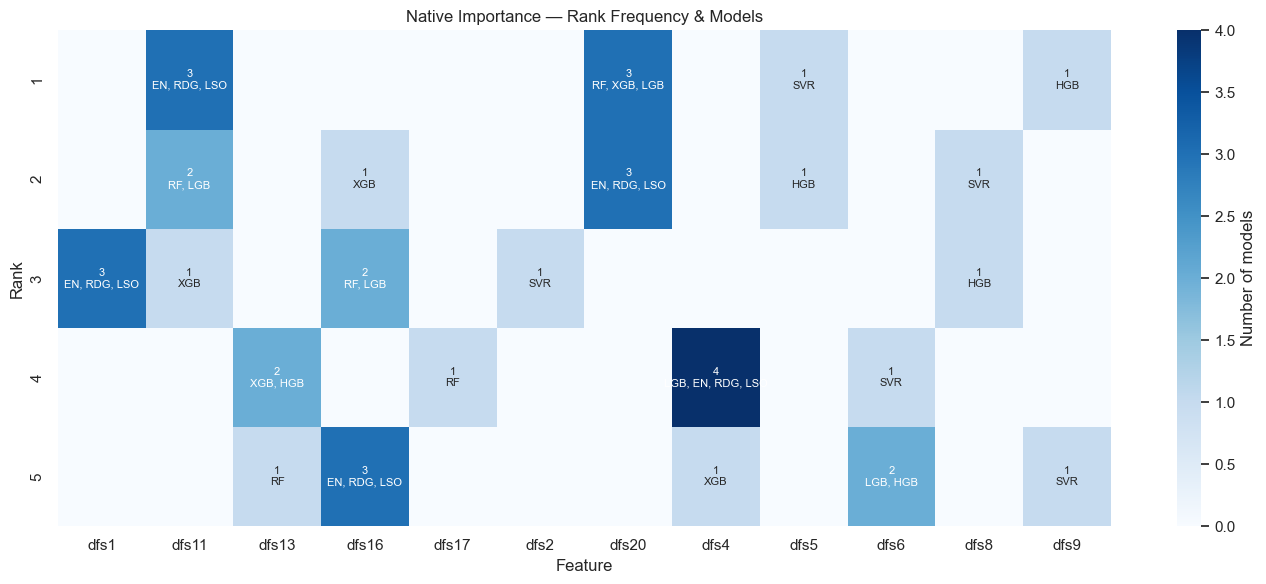

In [275]:
native_counts, native_annot = build_model_annotations(native_rank_df, top_n=5, model_abbrev=model_abbrev)
plot_rank_heatmap(native_counts, annot=native_annot, figsize=(14, 6), title='Native Importance — Rank Frequency & Models')